#лаб 6.1 Disbalanced dataset 1

- выполнила: Ахматова Ульяна, ИТХ-2-2021
- используемый датасет: creditcart (https://drive.google.com/file/d/13_lSUSV6IQBIP8CDG7xUp8JXmtNQxW-M/view?usp=sharing)

- транзакции, проведенные за два дня, где 492 случаев мошенничества из 284 807 транзакций. Набор данных сильно несбалансирован, положительный класс (мошенники) составляет всего 0,172% от всех транзакций.

- только числовые входные переменные, которые являются результатом преобразования PCA (метод главных компонент).

- характеристики V1, V2, ... V28 -  главные компоненты, полученные с помощью PCA, единственные характеристики, которые не были преобразованы с помощью PCA - это "Time" и "Amount". Столбец "Time" содержит секунды, прошедшие между каждой транзакцией и первой транзакцией в наборе данных. Столбец "Amount" - это сумма транзакции. Столбец "Class" является переменной отклика и принимает значение 1 в случае мошенничества и 0 в противном случае.


##Загрузка данных

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline


import seaborn as sns
import matplotlib.patches as mpatches
import time

import collections
from collections import Counter

import warnings
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv('/content/drive/MyDrive/creditcard.csv')

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


##Анализ данных

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [ ]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [ ]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

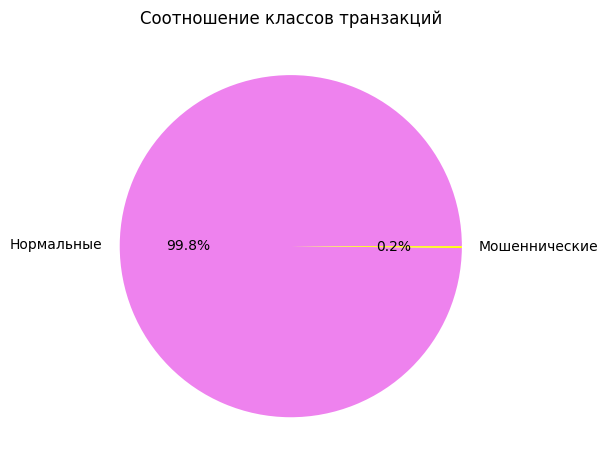

In [3]:
vals = df['Class'].unique() #уникальные значения
class_counts = df['Class'].value_counts()   #их количество

list_values = {'Нормальные': class_counts[0], 'Мошеннические': class_counts[1]}

plt.title('Соотношение классов транзакций')
plt.pie(list_values.values(), labels=list_values.keys(), autopct='%1.1f%%', colors=['violet', 'yellow'])
plt.tight_layout()

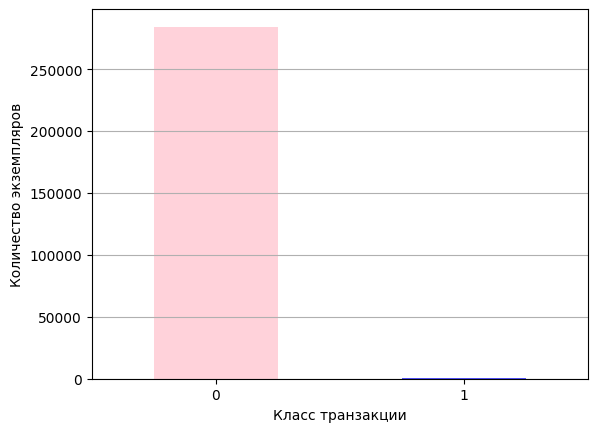

In [ ]:
class_counts.plot(kind='bar', color=['pink', 'blue'], alpha=0.7)
plt.xlabel('Класс транзакции')
plt.ylabel('Количество экземпляров')
plt.xticks(ticks=range(len(class_counts)), labels=class_counts.index, rotation=0)
plt.grid(axis='y')

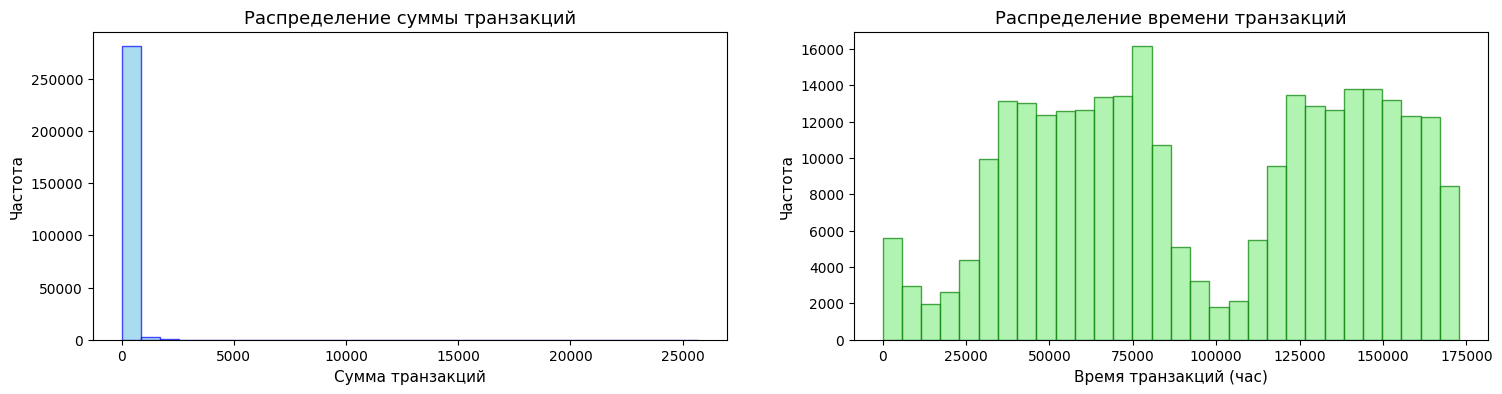

In [ ]:
#распределения по сумме и времени транзакций

fig, ax = plt.subplots(1, 2, figsize=(18, 4))
amount_val = df['Amount']
time_val = df['Time']


ax[0].hist(amount_val, bins=30, color='skyblue', edgecolor='blue', alpha=0.7)
ax[0].set_title('Распределение суммы транзакций', fontsize=13)
ax[0].set_xlabel('Сумма транзакций', fontsize=11)
ax[0].set_ylabel('Частота', fontsize=11)

ax[1].hist(time_val, bins=30, color='lightgreen', edgecolor='green', alpha=0.7)
ax[1].set_title('Распределение времени транзакций', fontsize=13)
ax[1].set_xlabel('Время транзакций (час)', fontsize=11)
ax[1].set_ylabel('Частота', fontsize=11)
plt.show()

##Масштабирование данных

###Метод Random Under-Sampling

Перед балансировкой необходимо разделить исходный набор данных.

Для определения качества работы моделей их необходимо тестировать на исходном тестовом наборе, а не на тестовом наборе, созданном после балансировки.

Цель балансировки заключается в том, чтобы модель смогла найти закономерности для принятия решения по типу транзакции, поэтому мы выравниваем соотношение между мошенническими транзакциями и обычными. Однако проверять качество надо в реальных условиях (исходные данные).

In [3]:
from sklearn.model_selection import train_test_split
# Поскольку большая часть наших данных уже масштабирована, мы должны масштабировать столбцы, которые остались (Amount и Time)
from sklearn.preprocessing import RobustScaler

rob_scaler = RobustScaler() # Менее чувствителен к выбросам, чем просто стандартизация

X = df.drop('Class', axis=1)
y = df['Class']

original_Xtrain, original_Xtest, original_ytrain, original_ytest = train_test_split(X, y, test_size=0.2, random_state = 42)

# Посмотрим, какие типы данных возвращаются после разделения:
rt_tmp = original_Xtrain['Amount']
print (f'Тип данных original_Xtrain["Amount"] {type(rt_tmp)}')

print (f'Тип данных original_Xtrain["Amount"].values {type(rt_tmp.values)}')
print (f'Данные original_Xtrain["Amount"].values {rt_tmp.values}')
print (f'Тип данных original_Xtrain["Amount"].values.reshape(-1,1) {type(rt_tmp.values.reshape(-1,1))}')
print (f'Данные original_Xtrain["Amount"].values.reshape(-1,1) \n{rt_tmp.values.reshape(-1,1)} \n')

Тип данных original_Xtrain["Amount"] <class 'pandas.core.series.Series'>
Тип данных original_Xtrain["Amount"].values <class 'numpy.ndarray'>
Данные original_Xtrain["Amount"].values [  9.99  45.9   11.99 ...   3.94   1.   113.  ]
Тип данных original_Xtrain["Amount"].values.reshape(-1,1) <class 'numpy.ndarray'>
Данные original_Xtrain["Amount"].values.reshape(-1,1) 
[[  9.99]
 [ 45.9 ]
 [ 11.99]
 ...
 [  3.94]
 [  1.  ]
 [113.  ]] 



Последнее представление - то, что нужно для RobustScaler . Преобразовываем так все остальные столбцы.

In [4]:
original_Xtrain['scaled_amount'] = rob_scaler.fit_transform(original_Xtrain['Amount'].values.reshape(-1,1))
original_Xtest['scaled_amount'] = rob_scaler.fit_transform(original_Xtest['Amount'].values.reshape(-1,1))

original_Xtrain['scaled_time'] = rob_scaler.fit_transform(original_Xtrain['Time'].values.reshape(-1,1))
original_Xtest['scaled_time'] = rob_scaler.fit_transform(original_Xtest['Time'].values.reshape(-1,1))

original_Xtrain.drop(['Time','Amount'], axis=1, inplace=True)
original_Xtest.drop(['Time','Amount'], axis=1, inplace=True)

#преобразование в массивы np
original_Xtrain = original_Xtrain.values
original_Xtest = original_Xtest.values
original_ytrain = original_ytrain.values
original_ytest = original_ytest.values

#количество классов и количество экземпляров в каждом классе для тренировочного и тестового наборов
train_unique_label, train_counts_label = np.unique(original_ytrain, return_counts=True)
test_unique_label, test_counts_label = np.unique(original_ytest, return_counts=True)

print('Распределение классов: \n')
print("Обучающий набор:", train_counts_label/ len(original_ytrain))
print("Тестовый набор:", test_counts_label/ len(original_ytest))

Распределение классов: 

Обучающий набор: [0.99827075 0.00172925]
Тестовый набор: [0.99827955 0.00172045]


In [5]:
# Поскольку наши классы сильно не сбалансированы, мы должны сделать их эквивалентными,
# чтобы получить нормальное распределение классов.

# Перемешаем данные перед созданием подвыборок

df = df.sample(frac=1)

fraud_df = df.loc[df['Class'] == 1]
non_fraud_df = df.loc[df['Class'] == 0][:492] # берем последние 492 транзакции

normal_distributed_df = pd.concat([fraud_df, non_fraud_df])

# Перемешивание строк датасета
new_df = normal_distributed_df.sample(frac=1, random_state=42)

new_df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
46641,42868.0,-2.294503,-0.281536,1.018272,-0.047743,0.971461,1.269685,-0.527826,1.377555,0.008989,...,0.234071,0.455164,-0.108377,-1.106953,0.320384,0.673695,0.195444,-0.098408,80.00,0
114271,73408.0,-2.869795,1.335667,-1.009530,1.693885,-0.741480,-0.796773,-2.614242,1.066636,-1.135497,...,0.528421,0.228027,-0.749298,-0.067179,0.215792,-0.453651,0.349191,0.198862,16.48,1
65687,51703.0,-0.902464,1.416134,1.548501,0.087870,-0.558273,-1.228535,0.438078,0.295465,-0.741595,...,-0.134062,-0.426710,0.062058,0.915229,-0.270650,0.036775,0.187921,0.121659,0.99,0
154694,102622.0,-2.877176,4.569649,-9.553069,4.441079,-3.653961,-1.877981,-3.514353,1.547608,-2.503304,...,1.272896,1.300268,-0.003950,-0.360848,-0.597526,-0.390901,0.592197,-0.241010,346.94,1
255556,157284.0,-0.242245,4.147186,-5.672349,6.493741,1.591168,-1.602523,-0.950463,0.722903,-4.128505,...,0.249023,-0.480286,-0.286080,-1.153575,-0.035571,0.559628,0.409446,0.221048,0.77,1


In [ ]:
new_df.shape

(984, 31)

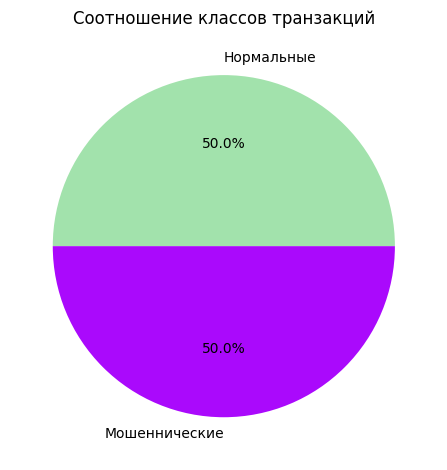

In [7]:
vals = new_df['Class'].unique() #уникальные значения
class_counts = new_df['Class'].value_counts()   #их количество

list_values = {'Нормальные': class_counts[0], 'Мошеннические': class_counts[1]}

plt.title('Соотношение классов транзакций')
plt.pie(list_values.values(), labels=list_values.keys(), autopct='%1.1f%%', colors=['#A2E2AC', '#AA09FC'])
plt.tight_layout()

ура сбалансировали

###Визуализация. Матрица корреляции

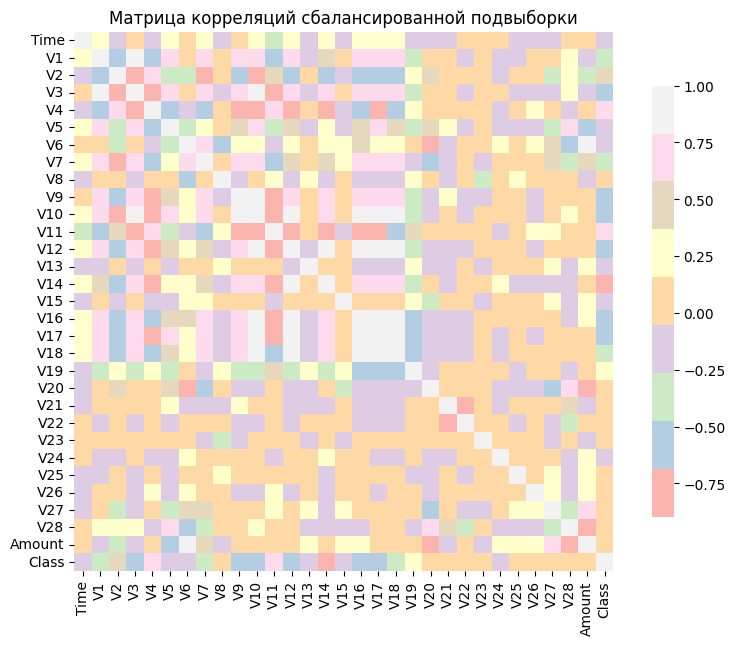

In [6]:
correlation_matrix = new_df.corr()

plt.figure(figsize=(10, 7))

sns.heatmap(correlation_matrix, annot=False, fmt='.2f', cmap='Pastel1', square=True, cbar_kws={"shrink": .8})
plt.title('Матрица корреляций сбалансированной подвыборки', fontsize=12)
plt.show()


<ul>
<li><b>Отрицательные корреляции: </b> Какие признаки  имеют отрицательную корреляцию? Другими словами, чем ниже эти значения, тем больше вероятность того, что конечным результатом будет мошенническая операция.  </li>
<li> <b> Положительные корреляции: </b> Какие признаки  положительно коррелируют? То есть, чем выше эти значения, тем больше вероятность того, что конечным результатом будет мошенническая операция. </li>
</ul>

In [9]:
corr = correlation_matrix['Class'].drop('Class')

# Отрицательные корреляции
negative_corr = corr[corr < 0].index.tolist()

# Положительные корреляции
positive_corr = corr[corr > 0].index.tolist()

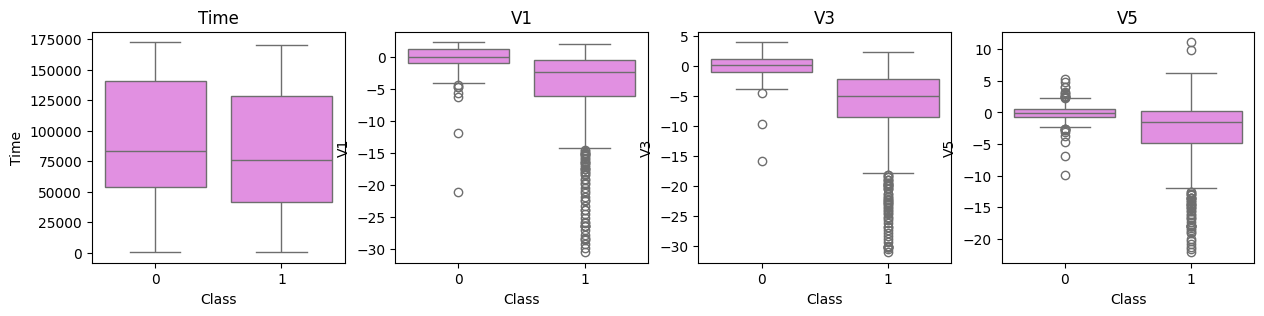

In [10]:
#для отрицательных корреляций
f, axes = plt.subplots(ncols=4, figsize=(15, 3))
for ax, feature in zip(axes, negative_corr):
    sns.boxplot(x='Class', y=feature, data=new_df, ax=ax, color = 'violet')
    ax.set_title(feature)
    ax.set_xlabel('Class')
    ax.set_ylabel(feature)

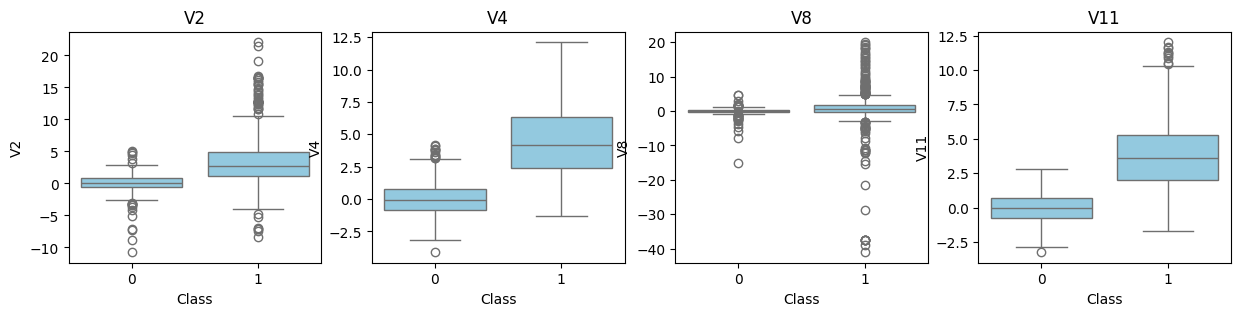

In [ ]:
#для положительных корреляций
f, axes = plt.subplots(ncols=4, figsize=(15, 3))
for ax, feature in zip(axes, positive_corr):
    sns.boxplot(x='Class', y=feature, data=new_df, ax=ax, color = 'skyblue')
    ax.set_title(feature)
    ax.set_xlabel('Class')
    ax.set_ylabel(feature)

###Обработка выбросов

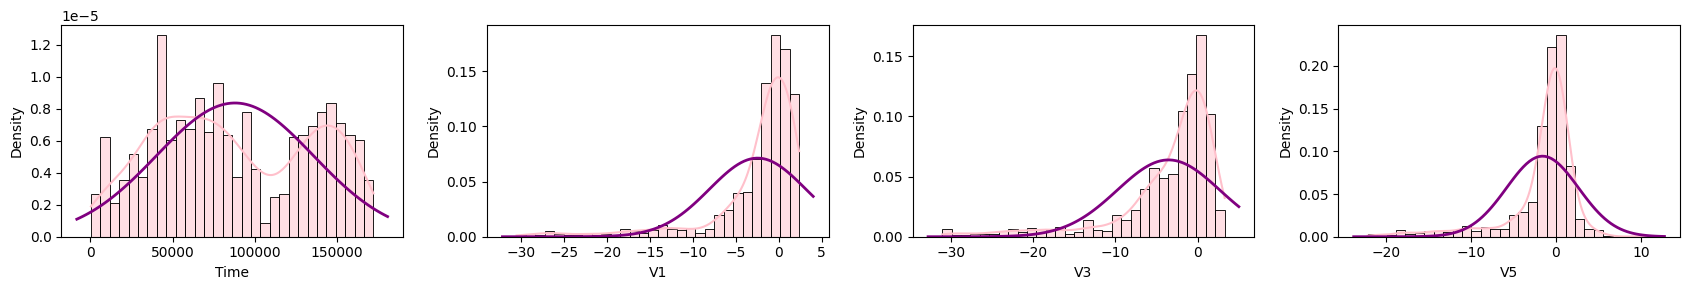

In [10]:
from scipy.stats import norm

f, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(17, 3))

for ax, feature in zip((ax1, ax2, ax3, ax4), negative_corr[:4]):
    sns.histplot(new_df[feature], bins=30, kde=True, ax=ax, stat="density", color='pink')

    mu, std = norm.fit(new_df[feature])
    xmin, xmax = ax.get_xlim()  #границы X
    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, mu, std)
    ax.plot(x, p, 'purple', linewidth=2)  #нормальное распределение
    ax.set_xlabel(feature, fontsize=10)

plt.tight_layout()
plt.show()

In [7]:
def remove(df, features):
    for feature in features:
      v_fraud = df[feature].loc[df['Class'] == 1].values
      #вычисление квартилей
      q25, q75 = np.percentile(v_fraud, 25), np.percentile(v_fraud, 75)
      v_iqr = q75 - q25
      print('Квартиль 25: {} | Квартиль 75: {}'.format(q25, q75))
      print('iqr: {}'.format(v_iqr))

      #определение порогов для выбросов
      v_cut_off = v_iqr * 1.5
      v_lower, v_upper = q25 - v_cut_off, q75 + v_cut_off
      print('Порог: {}'.format(v_cut_off))
      print('V17 нижняя граница: {}'.format(v_lower))
      print('V17 верхняя граница: {}'.format(v_upper))

      # Удаление выбросов
      outliers = [x for x in v_fraud if x < v_lower or x > v_upper]
      print('Количество выбросов: {}'.format(len(outliers)))
      df  = df.drop(df[(df[feature] > v_upper) | (df[feature] < v_lower)].index)
      print('-' * 50)
    return df


In [8]:
features = ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9',
                     'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16',
                     'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23',
                     'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Time']

new_df_without_outliers = remove(new_df, features)

Квартиль 25: -6.03606299434868 | Квартиль 75: -0.419200076257679
iqr: 5.616862918091001
Порог: 8.4252943771365
V17 нижняя граница: -14.461357371485182
V17 верхняя граница: 8.006094300878821
Количество выбросов: 52
--------------------------------------------------
Квартиль 25: 1.1086191157528824 | Квартиль 75: 3.9163736295138802
iqr: 2.807754513760998
Порог: 4.211631770641497
V17 нижняя граница: -3.1030126548886146
V17 верхняя граница: 8.128005400155377
Количество выбросов: 26
--------------------------------------------------
Квартиль 25: -6.559491963273132 | Квартиль 75: -1.985937229072785
iqr: 4.573554734200346
Порог: 6.86033210130052
V17 нижняя граница: -13.419824064573652
V17 верхняя граница: 4.874394872227734
Количество выбросов: 20
--------------------------------------------------
Квартиль 25: 2.0697508943387923 | Квартиль 75: 5.482320110285848
iqr: 3.4125692159470553
Порог: 5.118853823920583
V17 нижняя граница: -3.0491029295817906
V17 верхняя граница: 10.60117393420643
Количес

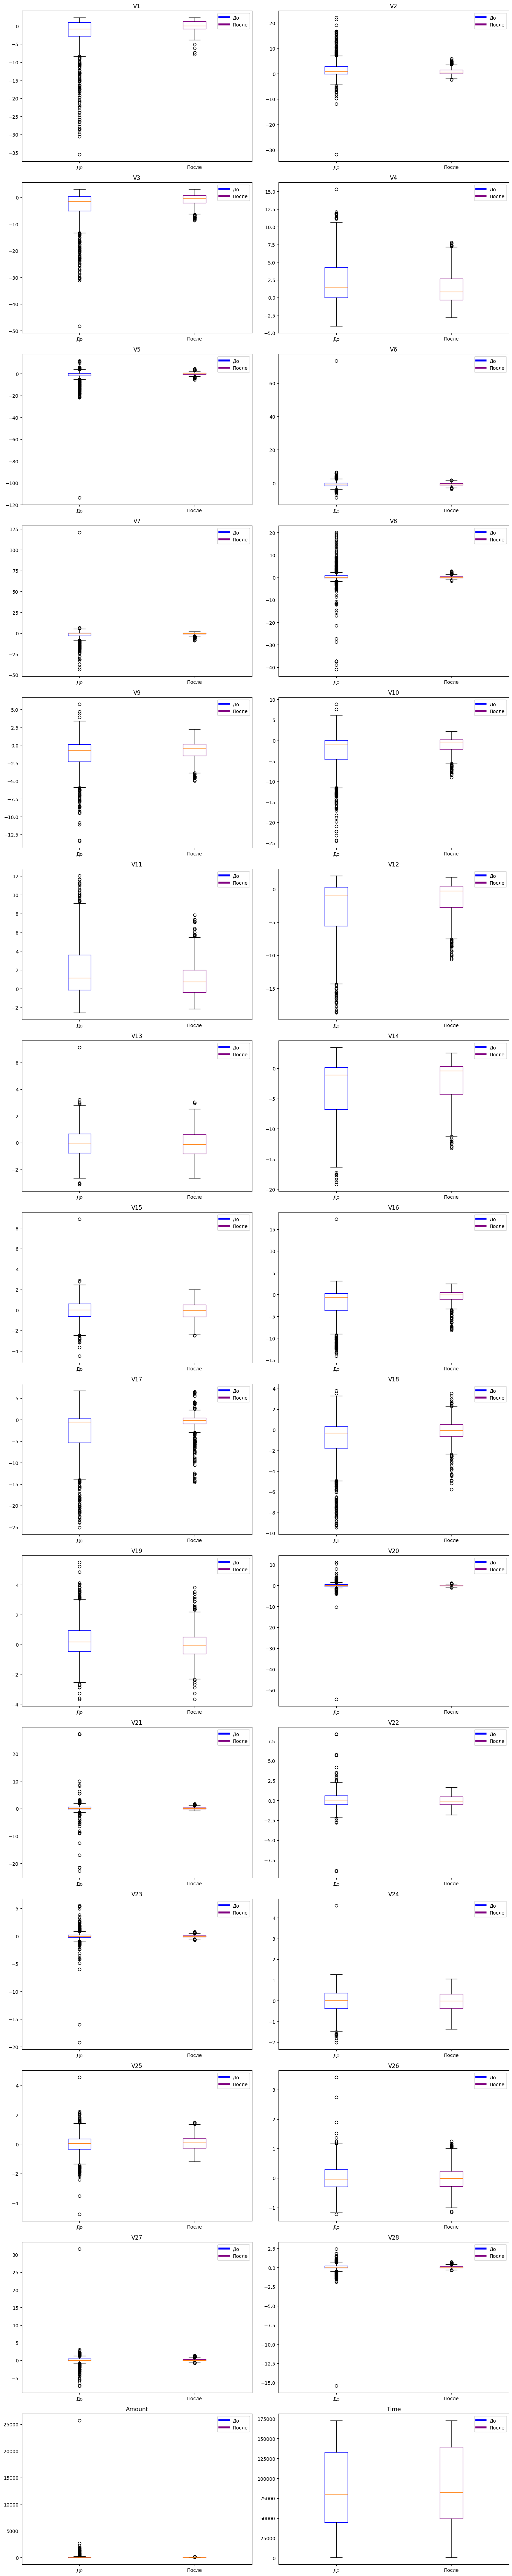

In [9]:
num_features = len(features)

num_cols = 2
num_rows = (num_features + num_cols - 1) // num_cols

# Создайте подграфики для визуализации
f, ax = plt.subplots(num_rows, num_cols, figsize=(15, 5 * num_rows))

for i, feature in enumerate(features):
    row = i // num_cols  #номер строки
    col = i % num_cols   #номер столбца

    #ДО
    ax[row, col].boxplot(new_df[feature], positions=[0], widths=0.2, boxprops=dict(color='blue'))

    #ПОСЛЕ
    ax[row, col].boxplot(new_df_without_outliers[feature], positions=[1], widths=0.2, boxprops=dict(color='purple'))

    ax[row, col].set_title(feature)
    ax[row, col].set_xticks([0, 1])
    ax[row, col].set_xticklabels(['До', 'После'])

    blue_box = plt.Line2D([0], [0], color='blue', lw=4, label='До')
    purple_box = plt.Line2D([0], [0], color='purple', lw=4, label='После')
    ax[row, col].legend(handles=[blue_box, purple_box])

#скрываем пустые подграфики
for i in range(num_features, num_rows * num_cols):
    ax.flatten()[i].axis('off')

plt.tight_layout()
plt.show()


###Понижение размерности и кластеризация

In [10]:
import time
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA, TruncatedSVD

X = new_df.drop('Class', axis=1)
y = new_df['Class']

#некоррелирующих признаков
X.drop(['Time', 'Amount'], axis=1, inplace=True)

#T-SNE
t0 = time.time()
tsne = TSNE(n_components=2, random_state=42)
X_reduced_tsne = tsne.fit_transform(X)
t1 = time.time()
print("T-SNE {:.2f} сек".format(t1 - t0))

#PCA
t0 = time.time()
pca = PCA(n_components=2, random_state=42)
X_reduced_pca = pca.fit_transform(X)
t1 = time.time()
print("PCA {:.2f} сек".format(t1 - t0))

#Truncated SVD
t0 = time.time()
svd = TruncatedSVD(n_components=2, random_state=42)
X_reduced_svd = svd.fit_transform(X)
t1 = time.time()
print("Truncated SVD {:.2f} сек".format(t1 - t0))


T-SNE 9.73 сек
PCA 0.00 сек
Truncated SVD 0.06 сек


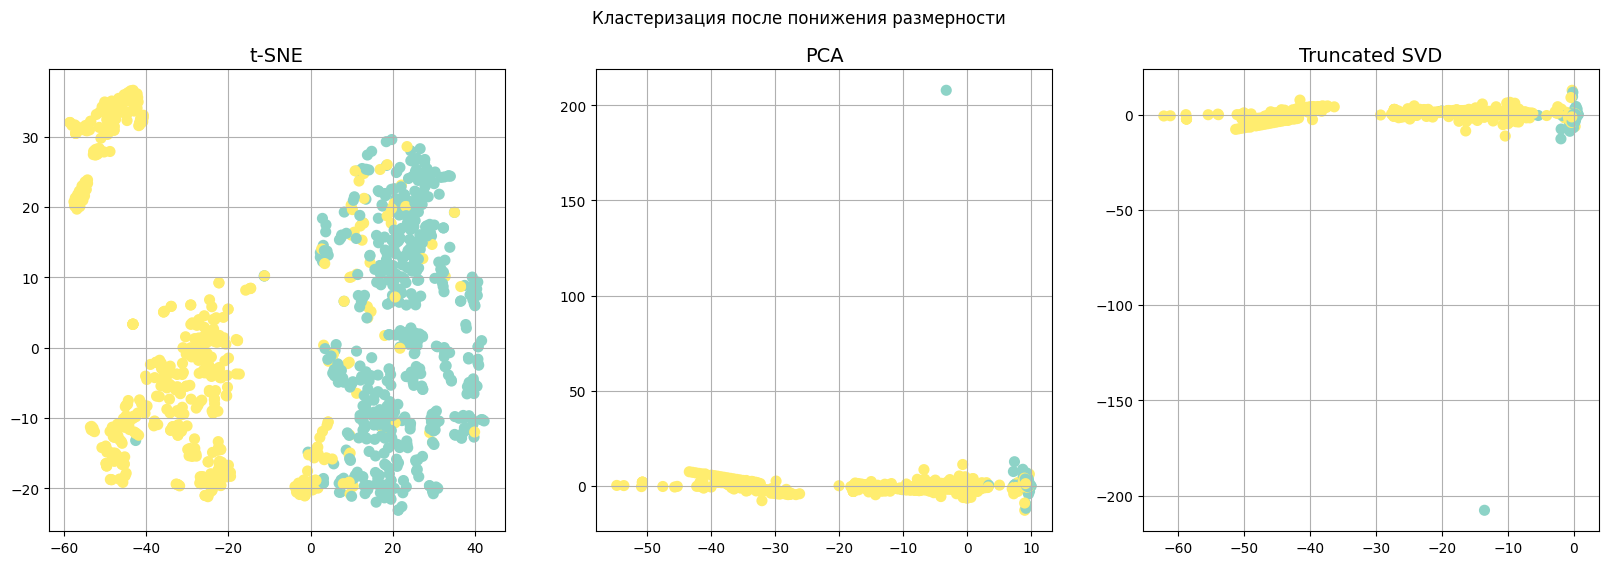

In [11]:
import matplotlib.patches as mpatches

f, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))
f.suptitle('Кластеризация после понижения размерности', fontsize=12)

# T-SNE scatter plot
sc1 = ax1.scatter(X_reduced_tsne[:, 0], X_reduced_tsne[:, 1], c=y, cmap= 'Set3', linewidths=2)
ax1.set_title('t-SNE', fontsize=14)
ax1.grid(True)

# PCA scatter plot
sc2 = ax2.scatter(X_reduced_pca[:, 0], X_reduced_pca[:, 1], c=y, cmap='Set3', linewidths=2)
ax2.set_title('PCA', fontsize=14)
ax2.grid(True)

# TruncatedSVD scatter plot
sc3 = ax3.scatter(X_reduced_svd[:, 0], X_reduced_svd[:, 1], c=y, cmap='Set3', linewidths=2)
ax3.set_title('Truncated SVD', fontsize=14)
ax3.grid(True)

plt.show()


#лаб 6.2. Disbalanced dataset. Credit card Fraud Detector

<li> Проанализировать полученные данные.</li>
<li> Решить проблему сильного дисбаланса классов.  </li>
<li>Построить модели на основе классических алгоритмов машинного обучения. </li>
<li> Провести сравнительный анализ классических подходов.</li>

In [17]:
new_df.head()   #полученные обновленные данные

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
225142,144123.0,1.707843,-0.980223,-2.407047,-0.426985,1.998541,3.614873,-0.559743,0.846400,0.597433,...,0.058382,-0.150042,0.122197,0.729812,-0.223057,0.230339,-0.050266,-0.032258,164.40,0
58761,48533.0,1.243848,0.524526,-0.538884,1.209196,0.479538,-0.197429,0.049166,0.037792,0.128119,...,-0.051660,-0.084089,-0.192846,-0.917392,0.681953,-0.194419,0.045917,0.040136,1.00,1
196294,131441.0,0.036062,0.715899,-1.393027,-0.145484,0.146947,-0.767973,0.664235,0.364033,-0.124763,...,0.374312,0.787515,0.077529,-0.636797,-0.265073,-0.136118,-0.117042,-0.056963,102.60,0
112840,72824.0,-1.111495,-0.257575,2.250210,1.152671,0.432904,1.254126,-0.584163,-0.609682,1.014602,...,0.862913,0.927825,-0.343058,-0.256268,-0.600742,-0.180331,0.026762,-0.358335,45.03,1
29687,35585.0,-2.019001,1.491270,0.005222,0.817253,0.973252,-0.639268,-0.974073,-3.146929,-0.003159,...,2.839596,-1.185443,-0.142812,-0.086103,-0.329113,0.523601,0.626283,0.152440,0.76,1


In [18]:
new_df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,...,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000
mean,87774.710366,-2.359237,1.779305,-3.521295,2.309550,-1.616900,-0.675703,-2.780147,0.297179,-1.302718,...,0.368578,-0.011606,-0.001731,-0.080086,0.001520,0.029679,0.081980,0.042696,110.790163,0.500000
std,48750.468042,5.534868,3.729250,6.232707,3.201169,4.190501,1.780913,5.868230,4.871661,2.301696,...,2.814037,1.174719,1.148525,0.570524,0.655995,0.475621,1.006974,0.445215,241.080995,0.500254
min,292.000000,-30.552380,-17.193065,-31.103685,-4.675470,-22.105532,-6.406267,-43.557242,-41.044261,-13.434066,...,-22.797604,-8.887017,-19.254328,-2.028024,-4.781606,-1.196978,-7.263482,-1.869290,0.000000,0.000000
25%,45388.000000,-2.791766,-0.180819,-5.113334,0.010286,-1.833226,-1.582428,-3.078361,-0.218506,-2.331368,...,-0.174797,-0.558031,-0.224426,-0.437941,-0.341107,-0.286776,-0.064245,-0.058987,1.290000,0.000000
50%,79154.500000,-0.760123,0.962931,-1.382163,1.363892,-0.425857,-0.660195,-0.621605,0.175208,-0.685249,...,0.133683,0.002237,-0.031730,-0.018820,0.015540,-0.010091,0.042921,0.031746,18.960000,0.500000
75%,135155.000000,1.040284,2.793742,0.314581,4.303707,0.414094,0.101404,0.279374,0.855025,0.204462,...,0.648533,0.533998,0.235911,0.358448,0.379259,0.324074,0.441092,0.212218,102.000000,1.000000
max,172532.000000,2.350714,22.057729,3.894346,12.114672,11.095089,6.474115,9.658528,20.007208,4.687859,...,27.202839,8.361985,5.466230,1.185948,2.208209,2.745261,3.052358,5.457934,2407.720000,1.000000


In [19]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
85770,60933.0,1.313364,0.078507,-1.291610,-0.484040,2.140332,3.181172,-0.506492,0.805143,-0.073942,...,-0.343337,-1.147928,0.096240,0.946065,0.370113,0.110742,-0.021631,0.023449,0.89,0
104933,69294.0,-0.315911,-0.436308,1.547625,-1.348006,-0.593091,1.753575,-0.913081,0.603919,-2.729027,...,0.041413,0.584011,-0.001397,-1.057448,-0.610619,0.128048,0.096686,0.079754,25.00,0
51591,45026.0,1.167275,0.268688,0.387962,1.155165,-0.297208,-0.695205,0.117514,-0.085767,0.039216,...,0.073532,0.253204,-0.027356,0.397853,0.550676,-0.317656,0.026024,0.020027,9.82,0
109104,71218.0,-0.690500,1.223438,0.371170,0.808452,0.771832,1.374452,0.232980,0.746808,-0.717715,...,-0.037422,0.109673,-0.293057,-1.669954,0.164475,-0.134342,0.297296,0.116174,27.00,0
190339,128793.0,1.884428,-0.273134,-1.130506,1.758274,0.382639,0.528303,-0.124554,0.046826,-0.619496,...,0.044093,0.080762,0.077325,0.329201,-0.303906,2.310316,-0.217186,-0.081224,74.91,0


In [20]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.177057e-15,3.371003e-16,-1.399346e-15,2.093255e-15,1.005463e-15,1.495546e-15,-5.632310e-16,1.145622e-16,-2.411844e-15,...,1.602424e-16,-3.509965e-16,2.630540e-16,4.472748e-15,5.145851e-16,1.685701e-15,-3.660403e-16,-1.224708e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [12]:
X = new_df.drop('Class', axis=1)
y = new_df['Class']

In [13]:
#МАСШТАБИРОВАНИЕ используем RobustScaler

from sklearn.model_selection import train_test_split
# Поскольку большая часть наших данных уже масштабирована, мы должны масштабировать столбцы,
# которые остались (Amount и Time)
from sklearn.preprocessing import RobustScaler

rob_scaler = RobustScaler()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42,
                                                    stratify = y)

X_train['scaled_amount'] = rob_scaler.fit_transform(X_train['Amount'].values.reshape(-1,1))
X_test['scaled_amount'] = rob_scaler.fit_transform(X_test['Amount'].values.reshape(-1,1))

X_train['scaled_time'] = rob_scaler.fit_transform(X_train['Time'].values.reshape(-1,1))
X_test['scaled_time'] = rob_scaler.fit_transform(X_test['Time'].values.reshape(-1,1))


# удаляем из трейн и тест датасетов  столбцы Time и Amount,
# так как у нас уже есть их отмасштабированные версии
X_train.drop(['Time','Amount'], axis=1, inplace=True)
X_test.drop(['Time','Amount'], axis=1, inplace=True)

In [14]:
# Переводим данные в массив для подачи в классификатор
X_train = X_train.values
X_test = X_test.values
y_train = y_train.values
y_test = y_test.values

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# Выберем несколько простых моделей из библиотеки sklearn

classifiers = {
    "LogisiticRegression": LogisticRegression(),  # Логистическая регрессия
    "KNearest": SVC(),  # Метод опорных векторов
    "Support Vector Classifier": KNeighborsClassifier(),# Метод ближайших соседей
    "DecisionTreeClassifier": DecisionTreeClassifier() # Решающее дерево
}

- для борьбы с переобучением - кросс-валидация
- делим обучающую выборку на 5 фолдов и обучаем модели

In [16]:
from sklearn.model_selection import cross_val_score

for key, classifier in classifiers.items():
    #classifier.fit(X_train, y_train)
    training_score = cross_val_score(classifier, X_train, y_train, cv=5)
    print("Модель ", classifier.__class__.__name__, "получила на обучающей выборке", round(training_score.mean(), 2) * 100, "% accuracy score")

Модель  LogisticRegression получила на обучающей выборке 94.0 % accuracy score
Модель  SVC получила на обучающей выборке 93.0 % accuracy score
Модель  KNeighborsClassifier получила на обучающей выборке 94.0 % accuracy score
Модель  DecisionTreeClassifier получила на обучающей выборке 89.0 % accuracy score


In [17]:
# Используем поиск по сетке для подбора гиперпараметров
from sklearn.model_selection import GridSearchCV

# Логистическая регрессия
log_reg_params = {"penalty": ['l1', 'l2'], 'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]}

grid_log_reg = GridSearchCV(LogisticRegression(), log_reg_params)
grid_log_reg.fit(X_train, y_train)

# Выбираем лучшую модель
log_reg = grid_log_reg.best_estimator_ #  для Логистическая регрессия

# Метод ближайших соседей
knears_params = {"n_neighbors": list(range(2,7,1)), 'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute']}

grid_knears = GridSearchCV(KNeighborsClassifier(), knears_params)
grid_knears.fit(X_train, y_train)

knears_neighbors = grid_knears.best_estimator_# для  K ближайший соседей

# Метод опорных векторов
x = [1.0, 1000.0]
y = [0.9]
z = [4]
svc_params=[
            {'C': x,'kernel': ['rbf'],'gamma': y} ,
            {'C': x,'kernel': ['poly'],'gamma': y,'degree': z}
           ]
grid_svc=GridSearchCV(estimator = SVC(),
                        param_grid = svc_params,
                        scoring='accuracy',
                        cv=3,
                        n_jobs=-1)

grid_svc.fit(X_train, y_train)

svc = grid_svc.best_estimator_#  для SVM

# Решающее дерево
tree_params = {"criterion": ["gini", "entropy"], "max_depth": list(range(2,7,1)),
              "min_samples_leaf": list(range(5,7,1))}
grid_tree = GridSearchCV(DecisionTreeClassifier(), tree_params)
grid_tree.fit(X_train, y_train)

tree_clf = grid_tree.best_estimator_#  для решающий деревьев

In [18]:
# Проверим, как поменялись метрики

log_reg_score = cross_val_score(log_reg, X_train, y_train, cv=5)
print('Logistic Regression Cross Validation Score: ', round(log_reg_score.mean() * 100, 2).astype(str) + '%')


knears_score = cross_val_score(knears_neighbors, X_train, y_train, cv=5)
print('Knears Neighbors Cross Validation Score', round(knears_score.mean() * 100, 2).astype(str) + '%')

svc_score = cross_val_score(svc, X_train, y_train, cv=5)
print('Support Vector Classifier Cross Validation Score', round(svc_score.mean() * 100, 2).astype(str) + '%')

tree_score = cross_val_score(tree_clf, X_train, y_train, cv=5)
print('DecisionTree Classifier Cross Validation Score', round(tree_score.mean() * 100, 2).astype(str) + '%')

Logistic Regression Cross Validation Score:  93.9%
Knears Neighbors Cross Validation Score 94.54%
Support Vector Classifier Cross Validation Score 90.72%
DecisionTree Classifier Cross Validation Score 92.25%


некоторые улучшились (немного), некоторые, наоборот, ухудшились (тоже немного)

попробуем более умные способы undersampling. Например, с помощью NearMiss, который оценивает среднее расстояние между классами (библиотека для работы с несбалансированными даннными imblearn)

In [19]:
from imblearn.pipeline import make_pipeline as imbalanced_make_pipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import NearMiss
from imblearn.metrics import classification_report_imbalanced
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import RobustScaler

rob_scaler = RobustScaler()

skf = StratifiedKFold(n_splits=5, random_state=None, shuffle=False)

from sklearn.metrics import (precision_score, roc_auc_score, recall_score, f1_score, classification_report,
                             confusion_matrix, roc_curve, precision_recall_curve, accuracy_score)

undersample_X = df.drop('Class', axis=1)
undersample_y = df['Class']

undersample_Xtrain, undersample_Xtest, undersample_ytrain, undersample_ytest = train_test_split(undersample_X, undersample_y,
                                                                                                test_size = 0.2,
                                                                                                random_state=42,
                                                                                                stratify = undersample_y)#

undersample_Xtrain['scaled_amount'] = rob_scaler.fit_transform(undersample_Xtrain['Amount'].values.reshape(-1,1))#
undersample_Xtest['scaled_amount'] = rob_scaler.fit_transform(undersample_Xtest['Amount'].values.reshape(-1,1))#

undersample_Xtrain['scaled_time'] = rob_scaler.fit_transform(undersample_Xtrain['Time'].values.reshape(-1,1))#
undersample_Xtest['scaled_time'] = rob_scaler.fit_transform(undersample_Xtest['Time'].values.reshape(-1,1))#

undersample_Xtrain.drop(['Time','Amount'], axis=1, inplace=True)
undersample_Xtest.drop(['Time','Amount'], axis=1, inplace=True)

undersample_Xtrain = undersample_Xtrain.values
undersample_Xtest = undersample_Xtest.values
undersample_ytrain = undersample_ytrain.values
undersample_ytest = undersample_ytest.values

undersample_accuracy = []
undersample_precision = []
undersample_recall = []
undersample_f1 = []
undersample_auc = []

# Метод NearMiss
X_nearmiss, y_nearmiss = NearMiss().fit_resample(undersample_X.values, undersample_y.values)
print('NearMiss распределение классов: {}'.format(Counter(y_nearmiss)))
# Использовать сэмплирование будем во время кросс-валидации

for train, test in skf.split(undersample_Xtrain, undersample_ytrain):
    undersample_pipeline = imbalanced_make_pipeline(NearMiss(sampling_strategy='majority'), log_reg)#
    undersample_model = undersample_pipeline.fit(undersample_Xtrain[train], undersample_ytrain[train])#
    undersample_prediction = undersample_model.predict(undersample_Xtrain[test])#

    undersample_accuracy.append(undersample_pipeline.score(undersample_Xtrain[test],
                                                           undersample_ytrain[test]))
    undersample_precision.append(precision_score(undersample_ytrain[test], undersample_prediction))
    undersample_recall.append(recall_score(undersample_ytrain[test], undersample_prediction))
    undersample_f1.append(f1_score(undersample_ytrain[test], undersample_prediction))
    undersample_auc.append(roc_auc_score(undersample_ytrain[test], undersample_prediction))

NearMiss распределение классов: Counter({0: 492, 1: 492})


In [20]:
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import learning_curve
import seaborn as sn

In [21]:
def plot_learning_curves(estimator1, estimator2, estimator3, estimator4, X, y, ylim=None, cv=None,
                        n_jobs=-1, train_sizes=np.linspace(.1, 1.0, 5)):
    f, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2,2, figsize=(20,14), sharey=True)
    if ylim is not None:
        plt.ylim(*ylim)

    # Первая модель
    train_sizes, train_scores, test_scores = learning_curve(estimator1, X, y, cv=cv,
                                                            n_jobs=n_jobs, train_sizes=train_sizes)#
    train_scores_mean = np.mean(train_scores, axis=1)#
    train_scores_std = np.std(train_scores, axis=1)#
    test_scores_mean = np.mean(test_scores, axis=1)#
    test_scores_std = np.std(test_scores, axis=1)#
    ax1.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="#ff9124")
    ax1.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="#2492ff")
    ax1.plot(train_sizes, train_scores_mean, 'o-', color="#ff9124",
             label="Training score")
    ax1.plot(train_sizes, test_scores_mean, 'o-', color="#2492ff",
             label="Cross-validation score")
    ax1.set_title("Logistic Regression Learning Curve", fontsize=14)
    ax1.set_xlabel('Размер выборки')
    ax1.set_ylabel('Score')
    ax1.grid(True)
    ax1.legend(loc="best")

    # Вторая модель
    train_sizes, train_scores, test_scores = learning_curve(
        estimator2, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    ax2.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="#ff9124")
    ax2.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="#2492ff")
    ax2.plot(train_sizes, train_scores_mean, 'o-', color="#ff9124",
             label="Training score")
    ax2.plot(train_sizes, test_scores_mean, 'o-', color="#2492ff",
             label="Cross-validation score")
    ax2.set_title("Knears Neighbors Learning Curve", fontsize=14)
    ax2.set_xlabel('Размер выборки')
    ax2.set_ylabel('Score')
    ax2.grid(True)
    ax2.legend(loc="best")


    # Третья модель
    train_sizes, train_scores, test_scores = learning_curve(
        estimator3, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    ax3.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="#ff9124")
    ax3.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="#2492ff")
    ax3.plot(train_sizes, train_scores_mean, 'o-', color="#ff9124",
             label="Размер выборки")
    ax3.plot(train_sizes, test_scores_mean, 'o-', color="#2492ff",
             label="Cross-validation score")
    ax3.set_title("Support Vector Classifier \n Learning Curve", fontsize=14)
    ax3.set_xlabel('Training size (m)')
    ax3.set_ylabel('Score')
    ax3.grid(True)
    ax3.legend(loc="best")


    # Четвертая модель
    train_sizes, train_scores, test_scores = learning_curve(
        estimator4, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    ax4.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="#ff9124")
    ax4.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="#2492ff")
    ax4.plot(train_sizes, train_scores_mean, 'o-', color="#ff9124",
             label="Размер выборки")
    ax4.plot(train_sizes, test_scores_mean, 'o-', color="#2492ff",
             label="Cross-validation score")
    ax4.set_title("Decision Tree Classifier \n Learning Curve", fontsize=14)
    ax4.set_xlabel('Training size (m)')
    ax4.set_ylabel('Score')
    ax4.grid(True)
    ax4.legend(loc="best")

    return plt

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.10/dist-packages/matplotlib/pyplot.py'>

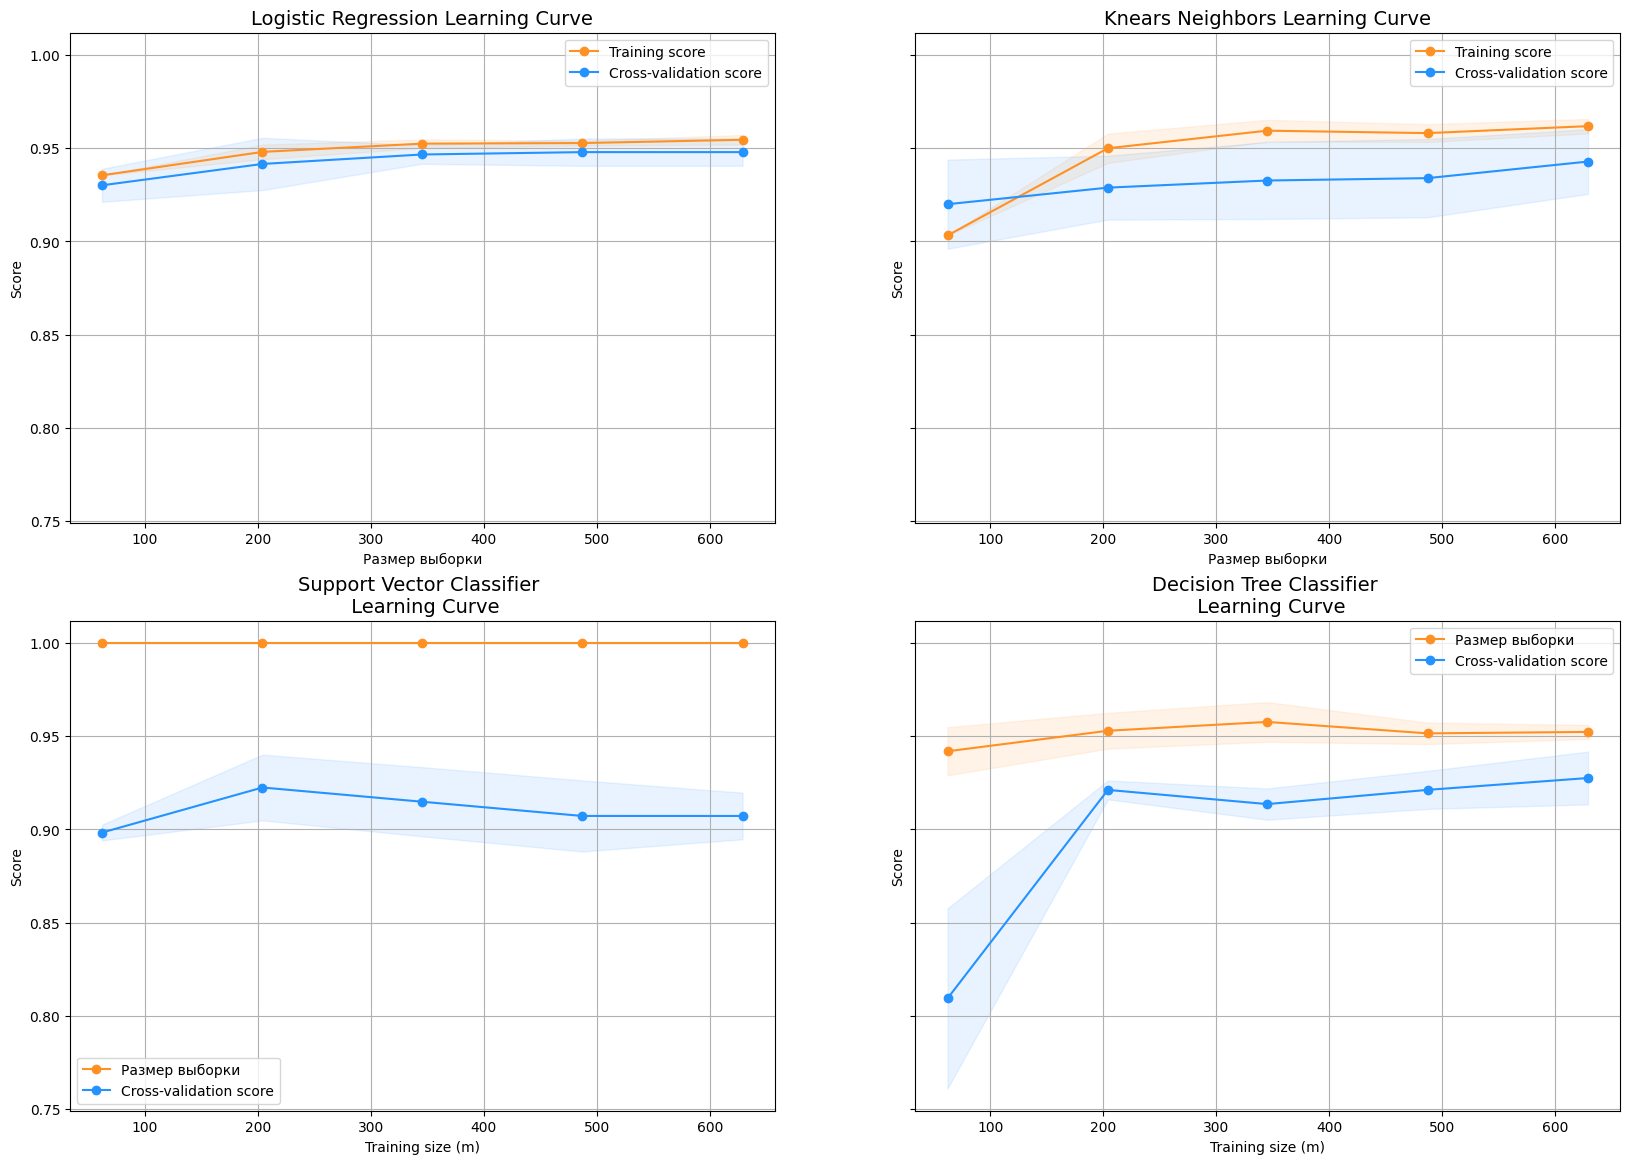

In [ ]:
cv = ShuffleSplit(n_splits=100, test_size=0.2, random_state=42)
plot_learning_curves(log_reg, knears_neighbors, svc, tree_clf, X_train, y_train)

##Кривые обучения

<ul>
<li>Чем больше разрыв между результатами обучения и результатами кросс-валидации, тем больше вероятность того, что модель переобучилась (большой разброс).</li>
<li> Если результаты низкие как на обучающем, так и на кросс-валидационном наборе, это указывает на то, что наша модель недообучилась (большое смещение).</li>
<li>Логистическая регрессия показала себя лучше остальных.</li>
</ul>

In [22]:
from sklearn.model_selection import cross_val_predict

log_reg_pred = cross_val_predict(log_reg, X_train, y_train, cv=5,
                             method="decision_function")

knears_pred = cross_val_predict(knears_neighbors, X_train, y_train, cv=5)

svc_pred = cross_val_predict(svc, X_train, y_train, cv=5,
                             method="decision_function")

tree_pred = cross_val_predict(tree_clf, X_train, y_train, cv=5)

In [23]:
print('Logistic Regression: ', roc_auc_score(y_train, log_reg_pred))
print('KNears Neighbors: ', roc_auc_score(y_train, knears_pred))
print('Support Vector Classifier: ', roc_auc_score(y_train, svc_pred))
print('Decision Tree Classifier: ', roc_auc_score(y_train, tree_pred))

Logistic Regression:  0.977841929192338
KNears Neighbors:  0.9454024101987832
Support Vector Classifier:  0.9218041616615645
Decision Tree Classifier:  0.9225500833107296


логистическая снова лучше остальных по метрикам

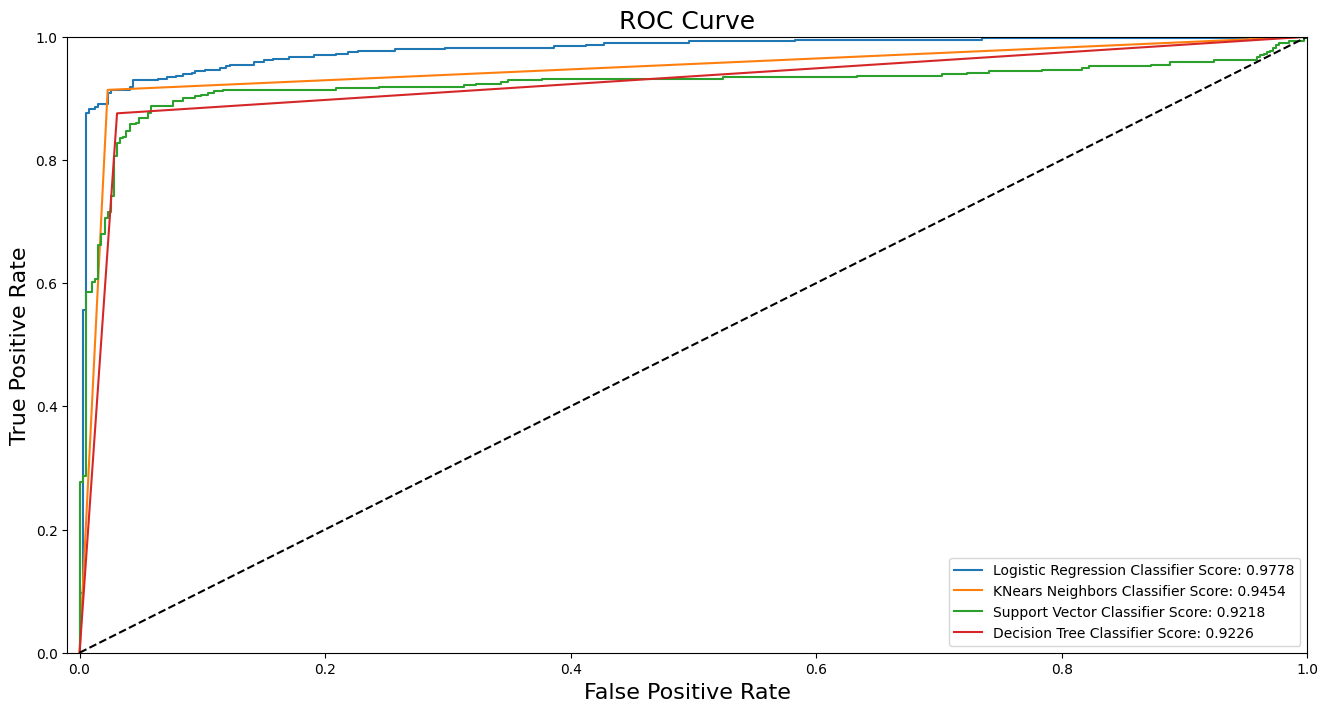

In [24]:
log_fpr, log_tpr, log_thresold = roc_curve(y_train, log_reg_pred)#
knear_fpr, knear_tpr, knear_threshold = roc_curve(y_train, knears_pred)#
svc_fpr, svc_tpr, svc_threshold = roc_curve(y_train, svc_pred)#
tree_fpr, tree_tpr, tree_threshold = roc_curve(y_train, tree_pred)#


def graph_roc_curve_multiple(log_fpr, log_tpr, knear_fpr, knear_tpr, svc_fpr, svc_tpr, tree_fpr, tree_tpr):
    plt.figure(figsize=(16,8))
    plt.title('ROC Curve', fontsize=18)
    plt.plot(log_fpr, log_tpr, label='Logistic Regression Classifier Score: {:.4f}'.format(roc_auc_score(y_train, log_reg_pred)))
    plt.plot(knear_fpr, knear_tpr, label='KNears Neighbors Classifier Score: {:.4f}'.format(roc_auc_score(y_train, knears_pred)))
    plt.plot(svc_fpr, svc_tpr, label='Support Vector Classifier Score: {:.4f}'.format(roc_auc_score(y_train, svc_pred)))
    plt.plot(tree_fpr, tree_tpr, label='Decision Tree Classifier Score: {:.4f}'.format(roc_auc_score(y_train, tree_pred)))
    plt.plot([0, 1], [0, 1], 'k--')
    plt.axis([-0.01, 1, 0, 1])
    plt.xlabel('False Positive Rate', fontsize=16)
    plt.ylabel('True Positive Rate', fontsize=16)
    plt.legend()

graph_roc_curve_multiple(log_fpr, log_tpr, knear_fpr, knear_tpr, svc_fpr, svc_tpr, tree_fpr, tree_tpr)
plt.show()

##SMOTE

<b>SMOTE</b> означает Synthetic Minority Over-sampling Technique.  В отличие от Random Under-Sampling, SMOTE создает новые синтетические точки для того, чтобы создать баланс классов. Это еще одна альтернатива для решения проблемы дисбаланса классов. <br><br>


<b> Принцип работы SMOTE: </b>
<ul>
<li><b>Генерация синтетических точек: </b> SMOTE выбирает расстояние между ближайшими соседями меньшего класса и между ними создает синтетические точки. </li>
<li> <b>Преимущество:  </b> Сохраняется больше информации, поскольку нам не пришлось удалять данные, в отличие от under-sampling.</li>
</ul>

### Правильное использование SMOTE
Если мы создадим синтетические точки перед кросс-валидацией, мы окажем определенное влияние на тестовое выборку. Но тестовая выборка не должна быть тронута! По этой причине мы должны создавать синтетические точки данных во время кросс-валидации, а не до нее.

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

rob_scaler = RobustScaler() # Менее чувствителен к выбросам, чем просто стандартизация

X = df.drop('Class', axis=1)
y = df['Class']

original_Xtrain, original_Xtest, original_ytrain, original_ytest = train_test_split(X, y, test_size=0.2,
                                                                                    random_state = 42)


original_Xtrain['scaled_amount'] = rob_scaler.fit_transform(original_Xtrain['Amount'].values.reshape(-1,1))
original_Xtest['scaled_amount'] = rob_scaler.fit_transform(original_Xtest['Amount'].values.reshape(-1,1))

original_Xtrain['scaled_time'] = rob_scaler.fit_transform(original_Xtrain['Time'].values.reshape(-1,1))
original_Xtest['scaled_time'] = rob_scaler.fit_transform(original_Xtest['Time'].values.reshape(-1,1))

original_Xtrain.drop(['Time','Amount'], axis=1, inplace=True)
original_Xtest.drop(['Time','Amount'], axis=1, inplace=True)

original_Xtrain = original_Xtrain.values
original_Xtest = original_Xtest.values
original_ytrain = original_ytrain.values
original_ytest = original_ytest.values

train_unique_label, train_counts_label = np.unique(original_ytrain, return_counts=True)
test_unique_label, test_counts_label = np.unique(original_ytest, return_counts=True)

print('Распределение классов: \n')
print("Обучающий набор:", train_counts_label/ len(original_ytrain))
print("Тестовый набор:", test_counts_label/ len(original_ytest))

Распределение классов: 

Обучающий набор: [0.99822248 0.00177752]
Тестовый набор: [0.99847267 0.00152733]


In [26]:
# сохраним параметры наших классификаторов, на которых они показали лучших результат с GridSearchCV

#dictionary of classifiers objects which we got in the above cell via GridSearchCV
#with the tuned parameters
tuned_classifiers = {
    "LogisiticRegression": log_reg,
    "Knears Neighbors": knears_neighbors,
    "Support Vector Classifier": svc,
    "DecisionTreeClassifier": tree_clf
}

#Making our Classifiers train with the tuned parameters
for key, classifier in tuned_classifiers.items():
    score = cross_val_score(classifier, X_train, y_train, cv=5)
    print(f'{key} Cross Validation Score: {round(score.mean() * 100, 2)}%')

LogisiticRegression Cross Validation Score: 93.9%
Knears Neighbors Cross Validation Score: 94.54%
Support Vector Classifier Cross Validation Score: 90.72%
DecisionTreeClassifier Cross Validation Score: 92.25%


In [27]:
#Over Sampling and under sampling libraries
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

#Machine learning Pipeline libraries
from imblearn.pipeline import Pipeline

# here we are using the imbalanced dataset
X = df.drop('Class', axis=1)
y = df['Class']

tuned_classifiers = {
    "LogisiticRegression": log_reg,
    "Knears Neighbors": knears_neighbors,
    #"Support Vector Classifier": svc,    #здесь оно ломалось почему-то или грузило миллион лет..
    "DecisionTreeClassifier": tree_clf
}

# StratifiedKFold is used for cross validation
# This cross-validation object is a variation of KFold that returns stratified folds.
# The folds are made by preserving the percentage of samples for each class.
sss = StratifiedKFold(n_splits=5, random_state=None, shuffle=False)

# creating the object for Over Sampling the minority class
over = SMOTE(sampling_strategy=0.01,k_neighbors=5)

# creating the object for Under Sampling the majority class
under = RandomUnderSampler(sampling_strategy=0.5)

# iterating thru the dictionary of tuned classifiers
for key, classifier in tuned_classifiers.items():

    # list of steps to be provided to the ML Pipeline
    steps=[('o',over),('u',under),('model',classifier)]

    # Creating a ML Pipeline
    FiPipeline=Pipeline(steps=steps)

    # Cross validating the classifiers
    scores=cross_val_score(FiPipeline, X, y, cv=sss)

    # Printing the mean accuracy score
    print(f"Classifiers: {key} Has a training score of, {round(scores.mean() * 100, 2)} % accuracy score")

Classifiers: LogisiticRegression Has a training score of, 98.56 % accuracy score
Classifiers: Knears Neighbors Has a training score of, 86.05 % accuracy score
Classifiers: DecisionTreeClassifier Has a training score of, 98.63 % accuracy score


In [28]:
# taking a fold of a data to do GridSearchCV for best parameters for SMOTE
for train_index, test_index in sss.split(X, y):
    original_Xtrain, original_Xtest = X.iloc[train_index], X.iloc[test_index]
    original_ytrain, original_ytest = y.iloc[train_index], y.iloc[test_index]

# creating a ML pipeline
model = Pipeline([
        ('sampling', SMOTE(sampling_strategy=0.01)),
        ('Random',RandomUnderSampler(sampling_strategy=0.5)),
        ('classification', log_reg)
    ])

# Running GridSearchCV on our ML pipeline by varying the k_neighbors from 1 to 10
# to find the best k_neighbors parameter value
# NOTE :- in paramgrid use above key + 2 _ followed by parameter
SMOTE_KN = GridSearchCV(model,{'sampling__k_neighbors':list(range(1,10))})
SMOTE_KN.fit(original_Xtrain,original_ytrain)

print(SMOTE_KN.best_estimator_)
print(SMOTE_KN.best_score_)
print(SMOTE_KN.best_params_)

# Training logistic regression classifier using SMOTE best parameter value for k_neighbors parameter
log_reg_score = cross_val_score(SMOTE_KN.best_estimator_, original_Xtrain, original_ytrain, cv=5)

# printing the mean accuracy score
print(f'Logistic Regression Cross Validation Score: {round(log_reg_score.mean() * 100, 2)}%')

Pipeline(steps=[('sampling', SMOTE(k_neighbors=9, sampling_strategy=0.01)),
                ('Random', RandomUnderSampler(sampling_strategy=0.5)),
                ('classification', LogisticRegression(C=1))])
0.9887994557857802
{'sampling__k_neighbors': 9}
Logistic Regression Cross Validation Score: 98.81%


In [29]:
labels = ['Non Fraud', 'Fraud']

best_est = SMOTE_KN.best_estimator_
smote_prediction = best_est.predict(original_Xtest)
print(classification_report(original_ytest, smote_prediction, target_names=labels))

              precision    recall  f1-score   support

   Non Fraud       1.00      0.99      0.99     56863
       Fraud       0.11      0.81      0.19        98

    accuracy                           0.99     56961
   macro avg       0.55      0.90      0.59     56961
weighted avg       1.00      0.99      0.99     56961



In [30]:
y_score = best_est.decision_function(original_Xtest)

In [31]:
sm = SMOTE(sampling_strategy='minority', random_state=42)

# Применим SMOTE после кросс-валидации
Xsm_train, ysm_train = sm.fit_resample(original_Xtrain, original_ytrain)

In [32]:
# Обучим логистическую регрессию
t0 = time.time()
log_reg_sm = grid_log_reg.best_estimator_
log_reg_sm.fit(Xsm_train, ysm_train)
t1 = time.time()
print("Время обучения: {} сек".format(t1 - t0))

Время обучения: 11.863684177398682 сек


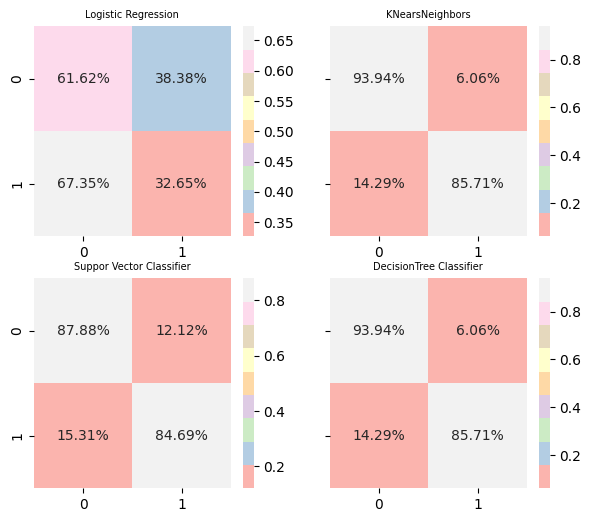

In [33]:
y_pred_log_reg = best_est.predict(X_test)

# Другие модели
y_pred_knear = knears_neighbors.predict(X_test)
y_pred_svc = svc.predict(X_test)
y_pred_tree = tree_clf.predict(X_test)


log_reg_cf = confusion_matrix(y_test, y_pred_log_reg, normalize='true')
kneighbors_cf = confusion_matrix(y_test, y_pred_knear, normalize='true')
svc_cf = confusion_matrix(y_test, y_pred_svc, normalize='true')
tree_cf = confusion_matrix(y_test, y_pred_tree, normalize='true')

fig,  ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(7, 6), sharey=True)
# Построим матрицы ошибок
sns.heatmap(ax=ax1, data=log_reg_cf, annot=True, fmt='.2%', cmap='Pastel1')
ax1.set_title("Logistic Regression", fontsize=7)



#
sns.heatmap(ax=ax2,data=kneighbors_cf, annot=True, fmt='.2%', cmap='Pastel1')
ax2.set_title("KNearsNeighbors", fontsize=7)


#
sns.heatmap(ax=ax3, data=svc_cf, annot=True,
            fmt='.2%', cmap='Pastel1')
ax3.set_title("Suppor Vector Classifier", fontsize=7)



#
sns.heatmap(ax=ax4, data=tree_cf, annot=True,
            fmt='.2%', cmap='Pastel1')
ax4.set_title("DecisionTree Classifier", fontsize=7)


plt.show()


* **Confusion matrix** : так же известна как матрица ошибок, состоит из 4 частей:

    * true positive (TP) : транзакция была мошеннической и модель предсказала ее как мошенническую
    * true negative (TN) : транзакция была нормальной и модель определила ее как нормальную
    * false positive (FP) : транзакция была нормальная, но модель среагировала на нее как на мошенническую
    * false negative (FN) : транзакция была мошенническая, но модель ее пропустила и посчитала нормальной


* **Метрики** :

    * Accuracy : (TP +TN) / (TP + TN + FP +FN)
    * Precision : TP / (TP + FP) (подходит при дисбалансе)
    * Recall : TP / (TP + FN) (подходит при дисбалансе)
    * F1 score : 2 x ((Precision x Recall) / (Precision + Recall)) (подходит при дисбалансе)

* **Roc-кривая** : ROC-кривая строится путем отрисовки графика зависимости частоты истинных положительных результатов (TPR) от частоты ложных положительных результатов (FPR) при различных пороговых значениях.

In [34]:
from sklearn.metrics import classification_report



print('Logistic Regression:')
#
y_pred=  best_est.predict(original_Xtest)
print(classification_report(original_ytest, y_pred, target_names=labels))

print('KNears Neighbors:')
#
y_pred=  knears_neighbors.predict(original_Xtest)
print(classification_report(original_ytest, y_pred, target_names=labels))

print('Support Vector Classifier:')
#
y_pred=  svc.predict(original_Xtest)
print(classification_report(original_ytest, y_pred, target_names=labels))

print('Decision Tree Classifier:')
#
y_pred=  tree_clf.predict(original_Xtest)
print(classification_report(original_ytest, y_pred, target_names=labels))



Logistic Regression:
              precision    recall  f1-score   support

   Non Fraud       1.00      0.99      0.99     56863
       Fraud       0.11      0.81      0.19        98

    accuracy                           0.99     56961
   macro avg       0.55      0.90      0.59     56961
weighted avg       1.00      0.99      0.99     56961

KNears Neighbors:
              precision    recall  f1-score   support

   Non Fraud       1.00      1.00      1.00     56863
       Fraud       0.00      0.00      0.00        98

    accuracy                           1.00     56961
   macro avg       0.50      0.50      0.50     56961
weighted avg       1.00      1.00      1.00     56961

Support Vector Classifier:
              precision    recall  f1-score   support

   Non Fraud       1.00      1.00      1.00     56863
       Fraud       0.00      0.00      0.00        98

    accuracy                           1.00     56961
   macro avg       0.50      0.50      0.50     56961
weighted

In [35]:
# Логистическая регрессия с under-sampling
y_pred = log_reg.predict(original_Xtest)
undersample_score = accuracy_score(original_ytest, y_pred)

# Логистическая регрессия с over-sampling
y_pred_sm = best_est.predict(original_Xtest)
oversample_score = accuracy_score(original_ytest, y_pred_sm)

d = {'Метод': ['Random Under-Sampling', 'Oversampling (SMOTE)'], 'Score': [undersample_score, oversample_score]}
final_df = pd.DataFrame(data=d)

score = final_df['Score']
final_df.drop('Score', axis=1, inplace=True)
final_df.insert(1, 'Score', score)

final_df

,Метод,Score
0,Random Under-Sampling,0.985464
1,Oversampling (SMOTE),0.988360


##ADASYNE

— метод, который адаптивно генерирует синтетические примеры на основе плотности данных, что позволяет лучше моделировать сложные распределения

In [46]:
np.count_nonzero(y_train == 1)  #убедились, что данные есть

394

In [45]:
from imblearn.over_sampling import ADASYN

In [37]:
#stratifiedKFold для кросс-валидации
sss_adasyne = StratifiedKFold(n_splits=5, random_state=None, shuffle=False)
over_adasyne = ADASYN(sampling_strategy='auto', random_state=42)

In [38]:
classifiers = {
    "LogisiticRegression": log_reg,
    "Knears Neighbors": knears_neighbors,
    #"Support Vector Classifier": svc,
    "DecisionTreeClassifier": tree_clf
}

In [39]:
steps_log=[('over', over_adasyne), ('model',log_reg)]
FiPipeline_log=Pipeline(steps=steps_log)
scores_log=cross_val_score(FiPipeline_log,X,y,cv=sss_adasyne)
print(f"Classifiers: LogisiticRegression Has a training score of {round(scores_log.mean() * 100, 2)} % accuracy score")

Classifiers: LogisiticRegression Has a training score of 98.02 % accuracy score


In [42]:
#грузил примерно миллиард лет, так и не загрузил

steps_knn=[('over', over_adasyne), ('model',knears_neighbors)]
FiPipeline_kn=Pipeline(steps=steps_knn)
scores_knn = cross_val_score(FiPipeline_kn,X,y,cv=sss_adasyne)
print(f"KnearsNeighbors. training score of {round(scores_knn.mean() * 100, 4)} % accuracy score")

KeyboardInterrupt: 

In [40]:
scores_tr_a=[('o',over_adasyne), ('model',tree_clf)]
FiPipeline_tr_a=Pipeline(steps=scores_tr_a)
scores_tr_a=cross_val_score(FiPipeline_tr_a,X,y, cv=sss_adasyne)

print(f"DecisionTreeClassifier training score % of accuracy score")
print(f"ADASYN.\t{round(scores_tr_a.mean() * 100, 4)}")

DecisionTreeClassifier training score % of accuracy score
ADASYN.	97.5973


In [47]:
for train_index, test_index in sss_adasyne.split(X, y):
    original_Xtrain, original_Xtest = X.iloc[train_index], X.iloc[test_index]
    original_ytrain, original_ytest = y.iloc[train_index], y.iloc[test_index]

model = Pipeline([
        ('sampling', ADASYN(sampling_strategy=0.01)),
        ('Random',RandomUnderSampler(sampling_strategy=0.5)),
        ('classification', log_reg)
    ])

ADASYN_KN = GridSearchCV(model,{'sampling__n_neighbors':list(range(1,10))})
ADASYN_KN.fit(original_Xtrain, original_ytrain)

print(ADASYN_KN.best_estimator_)
print(ADASYN_KN.best_score_)
print(ADASYN_KN.best_params_)

log_reg_score_ad = cross_val_score(ADASYN_KN.best_estimator_, original_Xtrain, original_ytrain, cv=5)
print(f"Logistic Regression Cross Validation Score")
print(f'SMOTE.\t{round(log_reg_score.mean() * 100, 2)}%')
print(f'ADASYN.\t{round(log_reg_score_ad.mean() * 100, 2)}%')

Pipeline(steps=[('sampling', ADASYN(n_neighbors=6, sampling_strategy=0.01)),
                ('Random', RandomUnderSampler(sampling_strategy=0.5)),
                ('classification', LogisticRegression(C=1))])
0.9894929080315944
{'sampling__n_neighbors': 6}
Logistic Regression Cross Validation Score
SMOTE.	98.81%
ADASYN.	98.74%


In [49]:
labels = ['Non Fraud', 'Fraud']

best_est_ad = ADASYN_KN.best_estimator_
adasyn_prediction = best_est_ad.predict(original_Xtest)
print('ADASYN')
print(classification_report(original_ytest, adasyn_prediction, target_names=labels))
print('\nSMOTE')
print(classification_report(original_ytest, smote_prediction, target_names=labels))

ADASYN
              precision    recall  f1-score   support

   Non Fraud       1.00      0.99      0.99     56863
       Fraud       0.11      0.82      0.19        98

    accuracy                           0.99     56961
   macro avg       0.55      0.90      0.59     56961
weighted avg       1.00      0.99      0.99     56961


SMOTE
              precision    recall  f1-score   support

   Non Fraud       1.00      0.99      0.99     56863
       Fraud       0.11      0.81      0.19        98

    accuracy                           0.99     56961
   macro avg       0.55      0.90      0.59     56961
weighted avg       1.00      0.99      0.99     56961



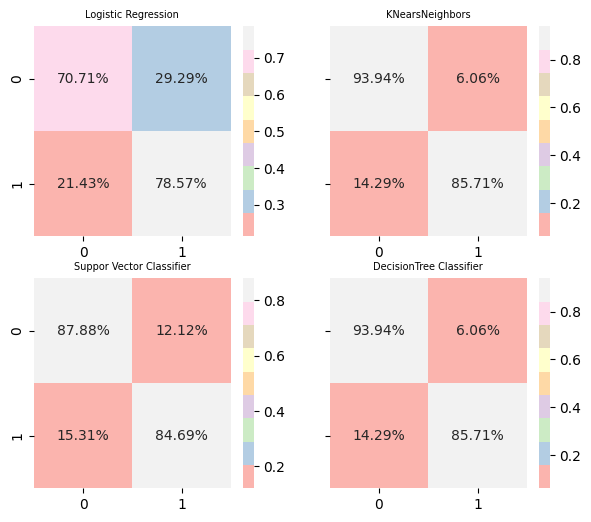

In [54]:
y_pred_log_reg_ad = best_est_ad.predict(X_test)
y_pred_knear_ad = knears_neighbors.predict(X_test)
y_pred_svc_ad = svc.predict(X_test)
y_pred_tree_ad = tree_clf.predict(X_test)

log_reg_cf_ad = confusion_matrix(y_test, y_pred_log_reg_ad, normalize='true')
kneighbors_cf_ad = confusion_matrix(y_test, y_pred_knear_ad, normalize='true')
svc_cf_ad = confusion_matrix(y_test, y_pred_svc_ad, normalize='true')
tree_cf_ad = confusion_matrix(y_test, y_pred_tree_ad, normalize='true')

fig,  ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2,figsize=(7, 6), sharey=True)

sns.heatmap(ax=ax1, data=log_reg_cf_ad, annot=True, fmt='.2%', cmap='Pastel1')
ax1.set_title("Logistic Regression", fontsize=7)

sns.heatmap(ax=ax2,data=kneighbors_cf_ad, annot=True, fmt='.2%', cmap='Pastel1')
ax2.set_title("KNearsNeighbors", fontsize=7)

sns.heatmap(ax=ax3, data=svc_cf_ad, annot=True, fmt='.2%', cmap='Pastel1')
ax3.set_title("Suppor Vector Classifier", fontsize=7)

sns.heatmap(ax=ax4, data=tree_cf_ad, annot=True, fmt='.2%', cmap='Pastel1')
ax4.set_title("DecisionTree Classifier", fontsize=7)
plt.show()

In [56]:
# Логистическая регрессия с under-sampling
y_pred = log_reg.predict(original_Xtest)
undersample_score = accuracy_score(original_ytest, y_pred)

# Логистическая регрессия с over-sampling
y_pred_ad = best_est_ad.predict(original_Xtest)
oversample_score_ad = accuracy_score(original_ytest, y_pred_ad)

d = {'Метод': ['Random Under-Sampling', 'Oversampling (ADASYN)'], 'Score': [undersample_score, oversample_score_ad]}
final_df_ad = pd.DataFrame(data=d)

score_ad = final_df_ad['Score']
final_df_ad.drop('Score', axis=1, inplace=True)
final_df_ad.insert(1, 'Score', score_ad)

final_df_ad

,Метод,Score
0,Random Under-Sampling,0.985464
1,Oversampling (ADASYN),0.988150
